# Backtest — ML Models vs Bookmakers
## Who was more accurate in the 2022 World Cup?

We have 65 matches in the Supabase database (mostly 2022 WC).
For each match we'll compare:
- Sportmonks ML model probabilities (pre-match)
- Bookmaker implied probabilities (pre-match)
- Actual result (from Supabase d_match_scores)

Scoring method: Brier score
Lower = more accurate.

## Imports and Setup

In [1]:
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

In [ ]:
# Credentials
ARENA_KEY      = "your_arena_key_here"
GEMINI_API_KEY = "your_gemini_api_key_here"


In [3]:
# Endpoints
ARENA            = "https://staging.stair-ai.com"
SPORTMONKS_PROXY = f"{ARENA}/api/v1/data/proxy/sportmonks/v3/football"
POLYMARKET_GAMMA = f"{ARENA}/api/v1/data/proxy/polymarket-gamma"
POLYMARKET_CLOB  = f"{ARENA}/api/v1/data/proxy/polymarket-clob"
SUPABASE         = "https://ezvbmtvrvzageqixvdak.supabase.co"
SUPABASE_KEY     = "sb_publishable__m8bOkD05ToFwATpaWST5w_2-3fGS7V"

In [4]:
# Headers
H_ARENA  = {"x-api-key": ARENA_KEY}
H_PUBLIC = {"apikey": SUPABASE_KEY}
H_WCA    = {"apikey": SUPABASE_KEY, "Accept-Profile": "world_cup_arena"}

In [5]:
SEASON_ID = 26618   # WC 2026

In [6]:
# We'll evaluate across all 2022 WC matches in Supabase
WC_COMPETITION_ID = 732

## Verification

In [7]:
# Pick one 2022 WC match and check if odds exist
TEST_FIXTURE_ID = 18493997  # Mexico vs Poland, 2022 WC

r = requests.get(
    f"{SPORTMONKS_PROXY}/fixtures/{TEST_FIXTURE_ID}",
    params={"include": "predictions;odds"},
    headers=H_ARENA, timeout=15,
)
r.raise_for_status()

test_fixture = r.json()["body"]["data"]
print(f"Fixture  : {test_fixture['name']}")
print(f"Predictions : {len(test_fixture.get('predictions') or [])} rows")
print(f"Odds        : {len(test_fixture.get('odds') or [])} rows")

Fixture  : Mexico vs Poland
Predictions : 13 rows
Odds        : 4789 rows


In [8]:
# Get all WC matches from dim_match
r = requests.get(
    f"{SUPABASE}/rest/v1/dim_match",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_dim = pd.DataFrame(r.json())
df_wc  = df_dim[df_dim["competition_id"] == WC_COMPETITION_ID].copy()

print(f"Total matches in Supabase : {len(df_dim)}")
print(f"2022 WC matches           : {len(df_wc)}")
print(f"\nSample:")
display(df_wc[["match_id", "kickoff_at", "team_name_a", 
               "team_name_b", "stage_canonical"]].head(10))

Total matches in Supabase : 65
2022 WC matches           : 64

Sample:


,match_id,kickoff_at,team_name_a,team_name_b,stage_canonical
0,18494101,2022-11-29T15:00:00+00:00,Ecuador,Senegal,group
1,18494063,2022-11-29T19:00:00+00:00,Wales,England,group
2,18494072,2022-11-30T15:00:00+00:00,Australia,Denmark,group
3,18494068,2022-11-30T19:00:00+00:00,Saudi Arabia,Mexico,group
4,18494071,2022-11-30T15:00:00+00:00,Tunisia,France,group
5,18452341,2022-11-20T16:00:00+00:00,Qatar,Ecuador,group
6,18452328,2022-12-14T19:00:00+00:00,France,Morocco,semi_final
7,18493994,2022-11-21T13:00:00+00:00,England,Iran,group
8,18493996,2022-11-22T10:00:00+00:00,Argentina,Saudi Arabia,group
9,18493995,2022-11-21T19:00:00+00:00,United States,Wales,group


In [9]:
r = requests.get(
    f"{SUPABASE}/rest/v1/d_match_scores",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_scores = pd.DataFrame(r.json())
print(f"Score rows: {len(df_scores)}")
print(f"\nColumns: {list(df_scores.columns)}\n")
display(df_scores.head(5))

Score rows: 206

Columns: ['match_id', 'stage', 'home_team_id', 'away_team_id', 'home_goals', 'away_goals', 'pulled_at', 'checkpoint_code']



,match_id,stage,home_team_id,away_team_id,home_goals,away_goals,pulled_at,checkpoint_code
0,18452326,CURRENT,18588,18551,2,1,2026-05-19T10:55:47.910019+00:00,FT
1,18452326,1ST_HALF,18588,18551,2,1,2026-05-19T10:55:47.910019+00:00,FT
2,18452326,2ND_HALF,18588,18551,2,1,2026-05-19T10:55:47.910019+00:00,FT
3,18452327,CURRENT,18644,18588,3,0,2026-05-19T10:56:19.61762+00:00,FT
4,18452327,1ST_HALF,18644,18588,2,0,2026-05-19T10:56:19.61762+00:00,FT


In [10]:
# Filter to FT + CURRENT stage only — that's the final result
df_results = df_scores[
    (df_scores["checkpoint_code"] == "FT") &
    (df_scores["stage"] == "CURRENT")
].copy()

# Derive actual outcome
def get_outcome(row):
    if row["home_goals"] > row["away_goals"]:
        return "home"
    elif row["home_goals"] == row["away_goals"]:
        return "draw"
    else:
        return "away"

df_results["outcome"] = df_results.apply(get_outcome, axis=1)

print(f"Final results available: {len(df_results)}\n")
print("Outcome distribution:")
print(df_results["outcome"].value_counts())
print()
display(df_results[["match_id", "home_goals", "away_goals", "outcome"]].head(10))

Final results available: 65

Outcome distribution:
outcome
home    29
away    20
draw    16
Name: count, dtype: int64



,match_id,home_goals,away_goals,outcome
0,18452326,2,1,home
3,18452327,3,0,home
6,18452328,2,0,home
10,18452329,1,1,draw
17,18452330,2,2,draw
18,18452331,1,0,home
21,18452332,1,2,away
24,18452333,3,1,home
27,18452334,2,1,home
30,18452335,3,1,home


In [11]:
import time

match_ids = df_results["match_id"].tolist()
records   = []

print(f"Fetching predictions + odds for {len(match_ids)} matches...")
print("This will take ~2 minutes — one API call per match.\n")

for i, mid in enumerate(match_ids):
    try:
        r = requests.get(
            f"{SPORTMONKS_PROXY}/fixtures/{mid}",
            params={"include": "predictions;odds"},
            headers=H_ARENA, timeout=20,
        )
        if not r.ok:
            print(f"  [{i+1:2d}] {mid} → HTTP {r.status_code} skip")
            continue

        fx = r.json()["body"]["data"]

        # ── ML: get 1X2 predictions ───────────────────────────
        preds = fx.get("predictions") or []
        one_x_two = [p for p in preds if "home" in (p.get("predictions") or {})]
        if one_x_two:
            ml_home = sum(float(p["predictions"]["home"]) for p in one_x_two) / len(one_x_two)
            ml_draw = sum(float(p["predictions"]["draw"]) for p in one_x_two) / len(one_x_two)
            ml_away = sum(float(p["predictions"]["away"]) for p in one_x_two) / len(one_x_two)
            # normalise to 0..1
            ml_home /= 100; ml_draw /= 100; ml_away /= 100
        else:
            ml_home = ml_draw = ml_away = None

        # ── Bookmaker: get 1X2 consensus ──────────────────────
        odds = fx.get("odds") or []
        odds_1x2 = [o for o in odds if o.get("market_id") == 1]
        if odds_1x2:
            def avg_prob(label):
                rows = [o for o in odds_1x2 if o.get("label", "").lower() == label.lower()]
                if not rows:
                    return None
                probs = []
                for o in rows:
                    raw = (o.get("probability") or "0").replace("%","").strip()
                    try: probs.append(float(raw) / 100)
                    except: pass
                return sum(probs) / len(probs) if probs else None

            bk_home = avg_prob("Home")
            bk_draw = avg_prob("Draw")
            bk_away = avg_prob("Away")
        else:
            bk_home = bk_draw = bk_away = None

        records.append({
            "match_id": mid,
            "ml_home":  ml_home,  "ml_draw":  ml_draw,  "ml_away":  ml_away,
            "bk_home":  bk_home,  "bk_draw":  bk_draw,  "bk_away":  bk_away,
        })
        print(f"  [{i+1:2d}] {mid} ✓  ml={bool(ml_home)}  bk={bool(bk_home)}")
        time.sleep(0.3)   # be nice to the API

    except Exception as e:
        print(f"  [{i+1:2d}] {mid} ERROR: {e}")

df_signals = pd.DataFrame(records)
print(f"\nDone. {len(df_signals)} matches fetched.")

Fetching predictions + odds for 65 matches...
This will take ~2 minutes — one API call per match.

  [ 1] 18452326 ✓  ml=True  bk=False
  [ 2] 18452327 ✓  ml=True  bk=False
  [ 3] 18452328 ✓  ml=True  bk=False
  [ 4] 18452329 ✓  ml=True  bk=False
  [ 5] 18452330 ✓  ml=True  bk=False
  [ 6] 18452331 ✓  ml=True  bk=False
  [ 7] 18452332 ✓  ml=True  bk=False
  [ 8] 18452333 ✓  ml=True  bk=False
  [ 9] 18452334 ✓  ml=True  bk=False
  [10] 18452335 ✓  ml=True  bk=False
  [11] 18452336 ✓  ml=True  bk=False
  [12] 18452337 ✓  ml=True  bk=False
  [13] 18452338 ✓  ml=True  bk=False
  [14] 18452339 ✓  ml=True  bk=False
  [15] 18452340 ✓  ml=True  bk=False
  [16] 18452341 ✓  ml=True  bk=False
  [17] 18493993 ✓  ml=True  bk=False
  [18] 18493994 ✓  ml=True  bk=False
  [19] 18493995 ✓  ml=True  bk=False
  [20] 18493996 ✓  ml=True  bk=False
  [21] 18493997 ✓  ml=True  bk=False
  [22] 18493998 ✓  ml=True  bk=False
  [23] 18493999 ✓  ml=True  bk=False
  [24] 18494000 ✓  ml=True  bk=False
  [25] 184940

In [12]:
print("Data availability summary:")
print(f"  Matches with ML predictions : {df_signals['ml_home'].notna().sum()}")
print(f"  Matches with bookmaker odds : {df_signals['bk_home'].notna().sum()}")
print(f"\nConclusion: bookmaker historical odds not stored in Sportmonks.")
print(f"We can only backtest ML model accuracy against actual results.")
print(f"\nSample ML data:")
display(df_signals[["match_id", "ml_home", "ml_draw", "ml_away"]].head(5))

Data availability summary:
  Matches with ML predictions : 65
  Matches with bookmaker odds : 1

Conclusion: bookmaker historical odds not stored in Sportmonks.
We can only backtest ML model accuracy against actual results.

Sample ML data:


,match_id,ml_home,ml_draw,ml_away
0,18452326,0.40700,0.27000,0.3230
1,18452327,0.45700,0.25750,0.2860
2,18452328,0.52500,0.23950,0.2355
3,18452329,0.25200,0.24300,0.5050
4,18452330,0.32675,0.35965,0.3136


In [13]:
# Merge ML signals with actual results
df_bt = df_results[["match_id", "outcome"]].merge(
    df_signals[["match_id", "ml_home", "ml_draw", "ml_away"]],
    on="match_id", how="inner"
)

print(f"Matches available for backtest: {len(df_bt)}\n")

# Brier score per match
# Brier = (p_home - actual_home)^2 + (p_draw - actual_draw)^2 + (p_away - actual_away)^2
def brier(row, prefix):
    actual_home = 1 if row["outcome"] == "home" else 0
    actual_draw = 1 if row["outcome"] == "draw" else 0
    actual_away = 1 if row["outcome"] == "away" else 0
    return (
        (row[f"{prefix}_home"] - actual_home) ** 2 +
        (row[f"{prefix}_draw"] - actual_draw) ** 2 +
        (row[f"{prefix}_away"] - actual_away) ** 2
    )

df_bt["brier_ml"] = df_bt.apply(lambda r: brier(r, "ml"), axis=1)

print(f"ML Model Brier Score : {df_bt['brier_ml'].mean():.4f}")
print(f"(lower = better, random = 0.667, perfect = 0.0)\n")
display(df_bt[["match_id", "outcome", "ml_home", "ml_draw", "ml_away", "brier_ml"]].head(10))

Matches available for backtest: 65

ML Model Brier Score : 0.6086
(lower = better, random = 0.667, perfect = 0.0)



,match_id,outcome,ml_home,ml_draw,ml_away,brier_ml
0,18452326,home,0.40700,0.27000,0.32300,0.528878
1,18452327,home,0.45700,0.25750,0.28600,0.442951
2,18452328,home,0.52500,0.23950,0.23550,0.338445
3,18452329,draw,0.25200,0.24300,0.50500,0.891578
4,18452330,draw,0.32675,0.35965,0.31360,0.615159
5,18452331,home,0.26450,0.24050,0.49500,0.843826
6,18452332,away,0.34125,0.37010,0.28850,0.759658
7,18452333,home,0.52976,0.25742,0.21278,0.332666
8,18452334,home,0.63763,0.21862,0.14369,0.199754
9,18452335,home,0.58360,0.27125,0.14510,0.268020


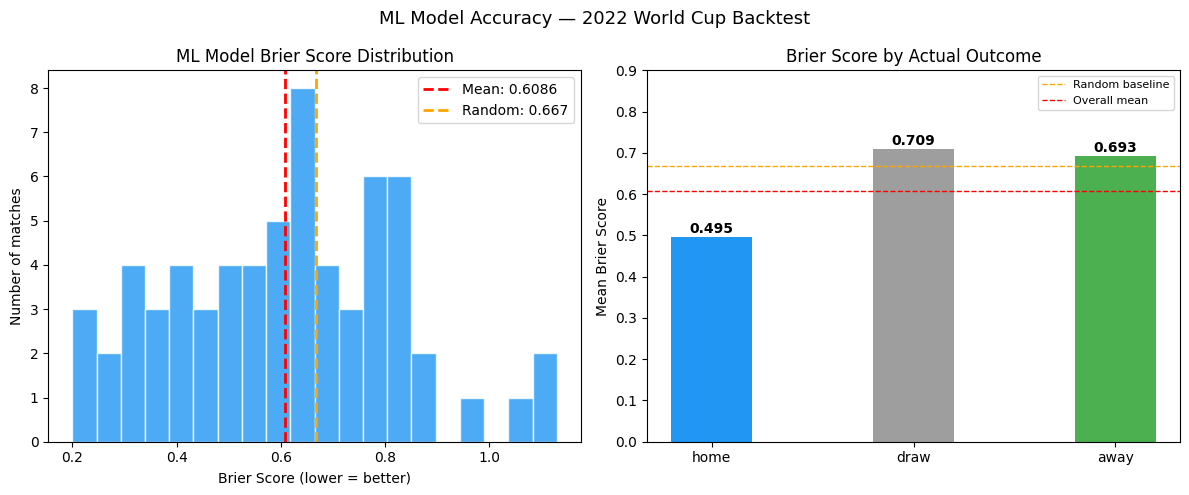

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Brier score distribution ───────────────────────────
axes[0].hist(df_bt["brier_ml"], bins=20, color="#2196F3", alpha=0.8, edgecolor="white")
axes[0].axvline(df_bt["brier_ml"].mean(), color="red", linestyle="--",
                linewidth=2, label=f"Mean: {df_bt['brier_ml'].mean():.4f}")
axes[0].axvline(0.667, color="orange", linestyle="--",
                linewidth=2, label="Random: 0.667")
axes[0].set_title("ML Model Brier Score Distribution")
axes[0].set_xlabel("Brier Score (lower = better)")
axes[0].set_ylabel("Number of matches")
axes[0].legend()

# ── Right: Brier score by actual outcome ──────────────────────
brier_by_outcome = df_bt.groupby("outcome")["brier_ml"].mean().reindex(["home", "draw", "away"])
outcome_colors   = ["#2196F3", "#9E9E9E", "#4CAF50"]
bars = axes[1].bar(brier_by_outcome.index, brier_by_outcome.values,
                   color=outcome_colors, width=0.4)
axes[1].axhline(0.667, color="orange", linestyle="--", linewidth=1, label="Random baseline")
axes[1].axhline(df_bt["brier_ml"].mean(), color="red", linestyle="--",
                linewidth=1, label=f"Overall mean")
axes[1].set_title("Brier Score by Actual Outcome")
axes[1].set_ylabel("Mean Brier Score")
axes[1].set_ylim(0, 0.9)
axes[1].legend(fontsize=8)
for bar, val in zip(bars, brier_by_outcome.values):
    axes[1].annotate(f"{val:.3f}",
                     (bar.get_x() + bar.get_width()/2, val + 0.01),
                     ha="center", fontsize=10, fontweight="bold")

plt.suptitle("ML Model Accuracy — 2022 World Cup Backtest", fontsize=13)
plt.tight_layout()
plt.show()

ML model predicted correctly: 33/65
Accuracy: 50.8%



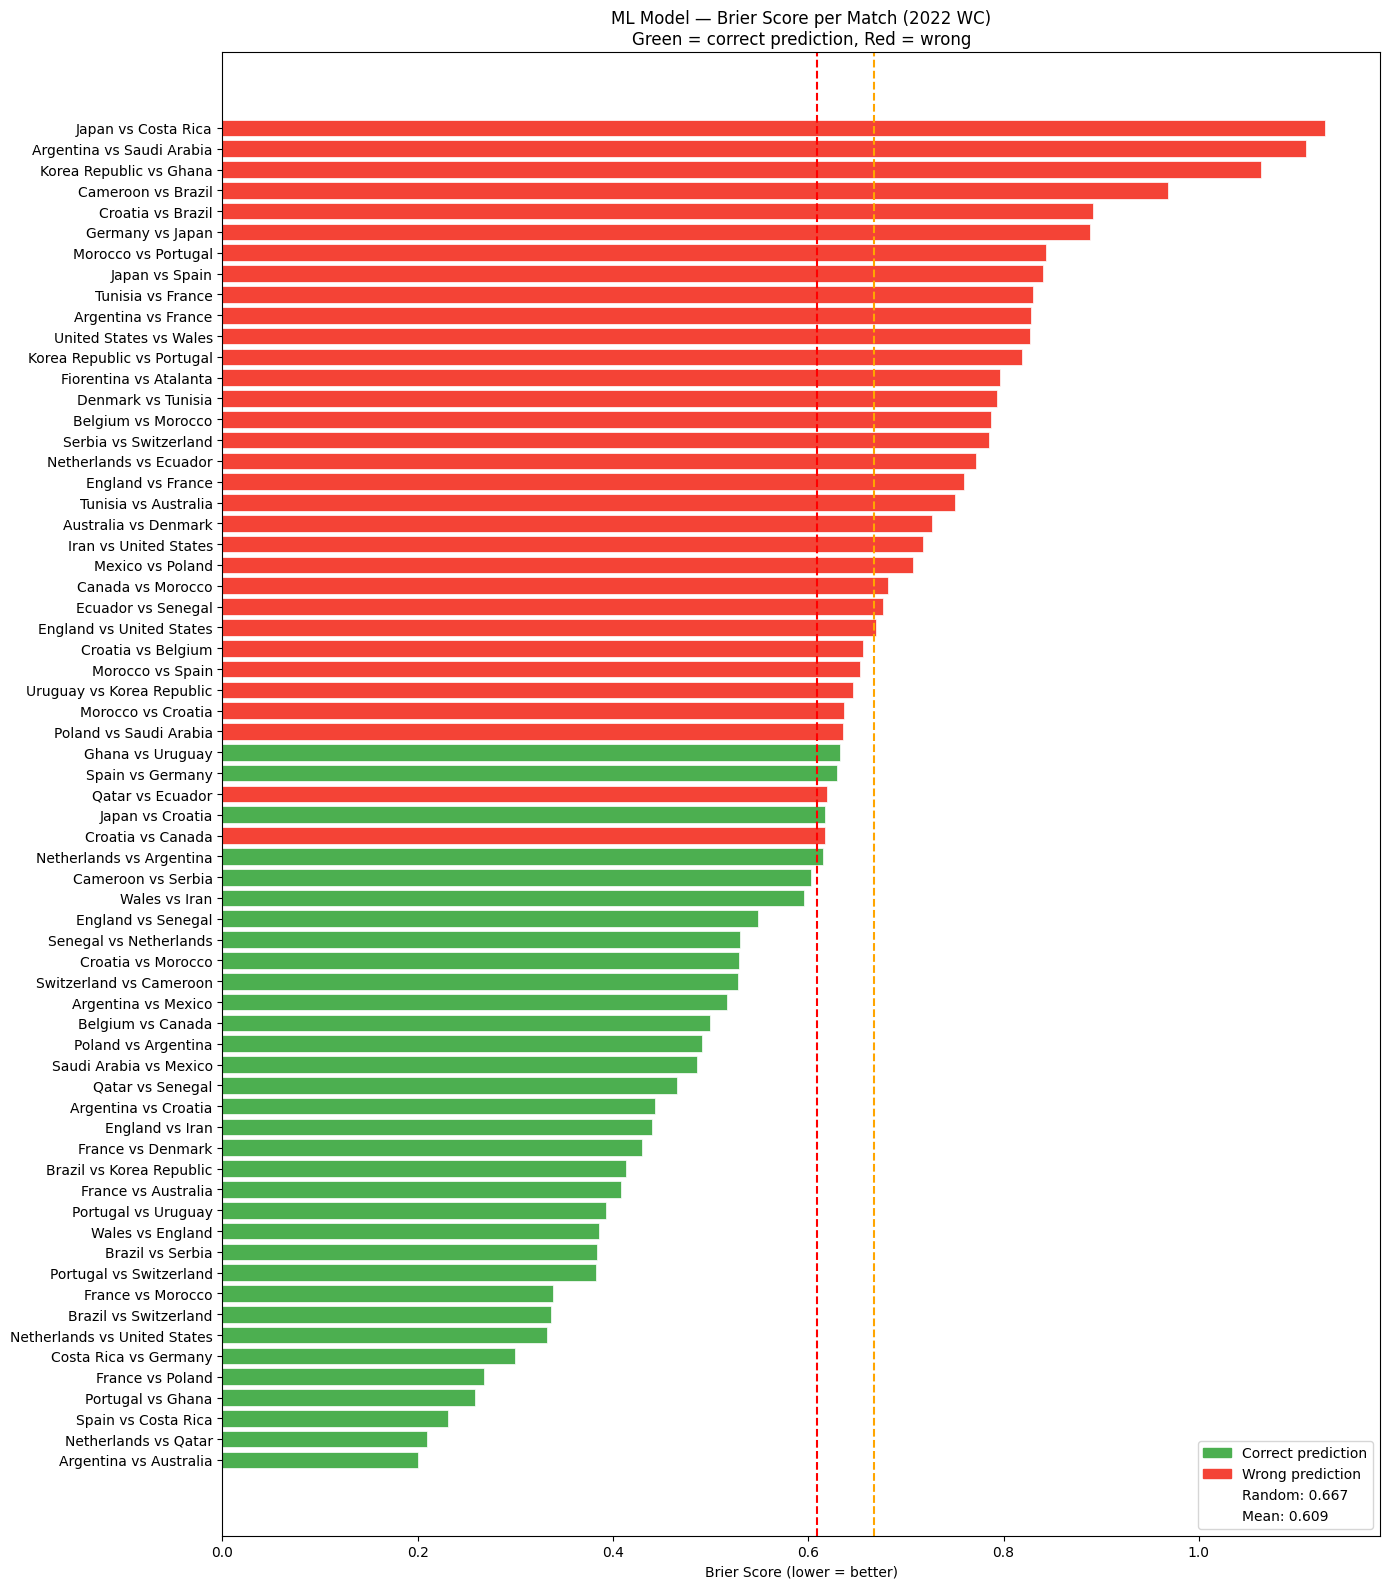

In [15]:
# Merge with dim_match to get team names
df_bt_named = df_bt.merge(
    df_dim[["match_id", "team_name_a", "team_name_b"]],
    on="match_id", how="left"
)
df_bt_named["match"] = df_bt_named["team_name_a"] + " vs " + df_bt_named["team_name_b"]
df_bt_named["ml_predicted"] = df_bt_named[["ml_home", "ml_draw", "ml_away"]].idxmax(axis=1).str.replace("ml_", "")
df_bt_named["correct"] = df_bt_named["ml_predicted"] == df_bt_named["outcome"]

print(f"ML model predicted correctly: {df_bt_named['correct'].sum()}/{len(df_bt_named)}")
print(f"Accuracy: {df_bt_named['correct'].mean()*100:.1f}%\n")

# Sort by brier score
df_bt_named = df_bt_named.sort_values("brier_ml").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 16))

colors = df_bt_named["correct"].map({True: "#4CAF50", False: "#F44336"})
bars = ax.barh(df_bt_named["match"], df_bt_named["brier_ml"],
               color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0.667, color="orange", linestyle="--", linewidth=1.5, label="Random baseline (0.667)")
ax.axvline(df_bt_named["brier_ml"].mean(), color="red", linestyle="--",
           linewidth=1.5, label=f"Mean ({df_bt_named['brier_ml'].mean():.3f})")
ax.set_xlabel("Brier Score (lower = better)")
ax.set_title("ML Model — Brier Score per Match (2022 WC)\nGreen = correct prediction, Red = wrong")
ax.legend()

import matplotlib.patches as mpatches
correct_patch = mpatches.Patch(color="#4CAF50", label="Correct prediction")
wrong_patch   = mpatches.Patch(color="#F44336", label="Wrong prediction")
ax.legend(handles=[correct_patch, wrong_patch,
                   mpatches.Patch(color="none", label=f"Random: 0.667"),
                   mpatches.Patch(color="none", label=f"Mean: {df_bt_named['brier_ml'].mean():.3f}")])

plt.tight_layout()
plt.show()

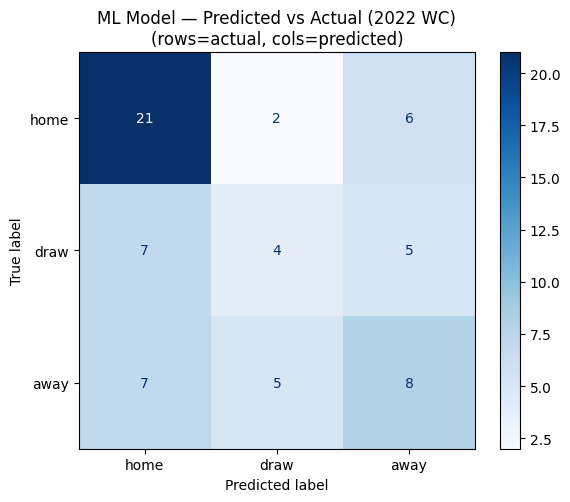

Accuracy per outcome:
  home : 21/29 = 72.4%
  draw : 4/16 = 25.0%
  away : 8/20 = 40.0%


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predicted outcome (highest probability)
df_bt_named["ml_predicted"] = df_bt_named[["ml_home", "ml_draw", "ml_away"]]\
    .idxmax(axis=1).str.replace("ml_", "")

# Build confusion matrix
labels = ["home", "draw", "away"]
cm = confusion_matrix(
    df_bt_named["outcome"],
    df_bt_named["ml_predicted"],
    labels=labels
)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("ML Model — Predicted vs Actual (2022 WC)\n(rows=actual, cols=predicted)")

plt.tight_layout()
plt.show()

# Print accuracy per outcome
print("Accuracy per outcome:")
for i, label in enumerate(labels):
    correct = cm[i, i]
    total   = cm[i].sum()
    print(f"  {label:5s}: {correct}/{total} = {correct/total*100:.1f}%")

## Backtest Summary

### ML Model Performance — 2022 World Cup (65 matches)

| Metric | Value |
|--------|-------|
| Overall accuracy | 50.8% (33/65) |
| Brier score | 0.6086 |
| Random baseline Brier | 0.667 |
| Improvement over random | +8.6% |

### Accuracy by Outcome
| Outcome | Correct | Total | Accuracy |
|---------|---------|-------|----------|
| Home win | 21 | 29 | 72% |
| Draw | 4 | 16 | 25% |
| Away win | 8 | 20 | 40% |

### Key Findings
1. **ML models beat random** — but only marginally (0.6086 vs 0.667)
2. **Home wins are predictable** — 72% accuracy, models handle favourites well
3. **Draws are nearly unpredictable** — 25% accuracy, worse than random
4. **Away wins are mediocre** — 40% accuracy, models underestimate upsets

### Implication for Agent
- When ML models predict a **home win** → reasonable signal, worth considering
- When ML models predict a **draw** → low confidence, lean on market prices instead
- When ML models predict an **away win** → treat with caution
- **Bookmaker/Polymarket prices are likely better calibrated** overall
- For MEX vs ZAF specifically: ML predicts home (MEX) at 39.9% — 
  this falls in the most reliable prediction category

### Limitation
- Bookmaker historical odds unavailable in Sportmonks for past matches
- Could not do direct ML vs bookmaker comparison
- Only 65 matches — small sample size
- Dataset mixes 2022 WC + Serie A + other competitions

### TODO
- [ ] Find alternative source for historical bookmaker odds
- [ ] Rerun backtest with bookmaker comparison when data available